In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Limpeza e Pré-processamento

In [3]:
# Carregando a base de dados
df = pd.read_csv('email_phishing_data.csv')

print(f"Tamanho original do dataset: {df.shape}")
df.head()

Tamanho original do dataset: (524846, 9)


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


In [4]:
# Removendo duplicatas
df = df.drop_duplicates()
print(f"Tamanho após remover duplicatas: {df.shape}")

Tamanho após remover duplicatas: (205052, 9)


In [5]:
# Removendo features redundantes
colunas_redundantes = ['num_stopwords', 'num_unique_domains']
df = df.drop(columns=colunas_redundantes, errors='ignore')
df.head()

,num_words,num_unique_words,num_links,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,0,0,0,0,0
1,5,5,0,0,0,0,0
2,34,32,0,0,0,0,0
3,6,6,0,0,0,0,0
4,9,9,0,0,0,0,0


In [6]:
# Separando features e target
X = df.drop('label', axis=1)
y = df['label']

X.head()

,num_words,num_unique_words,num_links,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,140,94,0,0,0,0
1,5,5,0,0,0,0
2,34,32,0,0,0,0
3,6,6,0,0,0,0
4,9,9,0,0,0,0


Cross-validation e Normalização

In [7]:
# Cross-validation
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Listas para guardar as métricas de cada rodada
recalls_por_fold = []
scaler = RobustScaler()  # Usando RobustScaler para lidar com outliers
fold = 1
dados_preparados = []

for train_index, test_index in skf.split(X, y):
    # Separando os dados de treino e teste para o fold atual
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Aplicar SMOTE apenas no conjunto de TREINO (para balancear as classes)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Normalização
    # (fit_transform) -> Calculando Mediana e IQR SOMENTE no conjunto de treino (agora balanceado)
    X_train_scaled = scaler.fit_transform(X_train_smote)

    # Aplicando a Normalização (transform) no conjunto de teste
    X_test_scaled = scaler.transform(X_test)

    # Guardando os dados prontos para posterior treinamento e avaliação do modelo
    dados_preparados.append({
        'fold': fold,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_smote,
        'y_test': y_test
    })

    fold += 1

# Vamos usar a primeira coluna (feature) como exemplo
nome_feature = X.columns[0]

# Exibindo resultado da normalizacão na feature "num_words"
print(f"\n--- Efeito da Normalização na feature: '{nome_feature}' ---")

# Estatísticas ANTES da normalização (usando o X original)
print("\n[ANTES] (Valores brutos da base original):")
print(f"Média         : {X[nome_feature].mean():.2f}")
print(f"Desvio Padrão : {X[nome_feature].std():.2f}")
print(f"Valor Máximo  : {X[nome_feature].max():.2f}")
print(f"\n[BALANCEAMENTO] Tamanho do Y de treino no Fold 1: {len(y_train)} instâncias")


# Estatísticas DEPOIS da normalização (usando o Fold 1 preparado)
X_treino_norm = dados_preparados[0]['X_train']
y_treino_norm = dados_preparados[0]['y_train']

print("\n[DEPOIS] (Valores transformados com RobustScaler no Fold 1):")
print(f"Média         : {X_treino_norm[:, 0].mean():.2f}")
print(f"Desvio Padrão : {X_treino_norm[:, 0].std():.2f}")
print(f"Valor Máximo  : {X_treino_norm[:, 0].max():.2f}")

print(f"\n[BALANCEAMENTO] Tamanho do Y de treino no Fold 1: {len(y_treino_norm)} instâncias")



--- Efeito da Normalização na feature: 'num_words' ---

[ANTES] (Valores brutos da base original):
Média         : 344.90
Desvio Padrão : 5255.02
Valor Máximo  : 2339682.00

[BALANCEAMENTO] Tamanho do Y de treino no Fold 1: 164042 instâncias

[DEPOIS] (Valores transformados com RobustScaler no Fold 1):
Média         : 0.73
Desvio Padrão : 18.51
Valor Máximo  : 10261.17

[BALANCEAMENTO] Tamanho do Y de treino no Fold 1: 318352 instâncias


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

valores_k = [1, 3, 5, 7, 9, 11, 13, 15]
metricas = ['euclidean', 'manhattan']


In [ ]:
resultados = []


for metrica in metricas:
    for k in valores_k:

        accs, precs, recalls, f1s = [], [], [], []

        for pacote in dados_preparados:

            X_treino = pacote['X_train']
            y_treino = pacote['y_train']
            X_teste = pacote['X_test']
            y_teste = pacote['y_test']

            modelo = KNeighborsClassifier(n_neighbors=k, metric=metrica)
            modelo.fit(X_treino, y_treino)

            y_pred = modelo.predict(X_teste)

            accs.append(accuracy_score(y_teste, y_pred))
            precs.append(precision_score(y_teste, y_pred, average='binary', pos_label=1))
            recalls.append(recall_score(y_teste, y_pred, average='binary', pos_label=1))
            f1s.append(f1_score(y_teste, y_pred, average='binary', pos_label=1))

        resultados.append({
            'Metrica': metrica,
            'K': k,
            'Accuracy': np.mean(accs),
            'Precision': np.mean(precs),
            'Recall': np.mean(recalls),
            'F1': np.mean(f1s),
            'Accuracy_std': np.std(accs),
            'F1_std': np.std(f1s)
        })

In [ ]:
df = pd.DataFrame(resultados)

# 5 melhores combinações
print("--- Top 5 Modelos KNN (Ordenados por Maior Recall) ---")
df_ordenado = df.sort_values(by='Recall', ascending=False)
display(df_ordenado.head())

# Pegando os hiperparâmetros do modelo vencedor (1ª linha da tabela)
melhor_k = df_ordenado.iloc[0]['K']
melhor_metrica = df_ordenado.iloc[0]['Metrica']

--- Top 5 Modelos KNN (Ordenados por Maior Recall) ---


,Metrica,K,Accuracy,Precision,Recall,F1,Accuracy_std,F1_std
15,manhattan,15,0.799344,0.085091,0.591189,0.148768,0.002179,0.004629
7,euclidean,15,0.801606,0.085574,0.587407,0.149384,0.001844,0.004252
14,manhattan,13,0.808551,0.086888,0.573758,0.150921,0.001484,0.004877
6,euclidean,13,0.810780,0.087329,0.569318,0.151429,0.001611,0.005089
13,manhattan,11,0.818744,0.089093,0.554188,0.153506,0.001855,0.005651


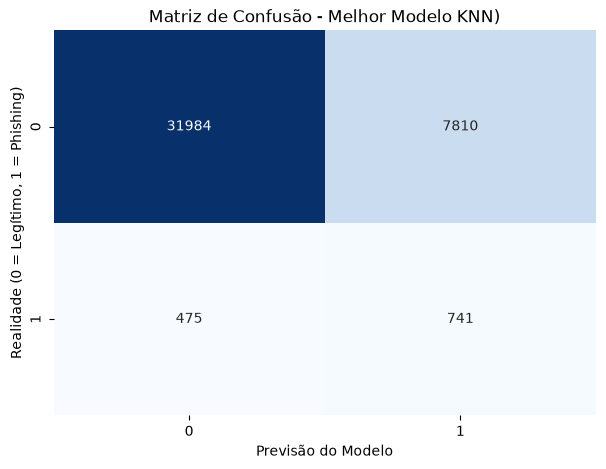

In [ ]:
# Fazendo o teste final no último fold
ultimo_fold = dados_preparados[-1]
X_treino_final = ultimo_fold['X_train']
y_treino_final = ultimo_fold['y_train']
X_teste_final = ultimo_fold['X_test']
y_teste_final = ultimo_fold['y_test']

# Treinando o modelo campeão
modelo_campeao = KNeighborsClassifier(n_neighbors=melhor_k, metric=melhor_metrica)
modelo_campeao.fit(X_treino_final, y_treino_final)
y_pred_final = modelo_campeao.predict(X_teste_final)

# Matriz de Confusão
cm = confusion_matrix(y_teste_final, y_pred_final)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusão - Melhor Modelo KNN)')
plt.ylabel('Realidade (0 = Legítimo, 1 = Phishing)')
plt.xlabel('Previsão do Modelo')
plt.show()

## Árvores de Decisão e Random Forest

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

max_depth = [5, 10, 15, 20]
criterion = ['gini', 'entropy']
min_samples_split = [2, 5, 10]

In [ ]:
resultados_dt = []
resultados_rf = []

for depth in max_depth:
    for crit in criterion:
        for min_split in min_samples_split:
            print(f"Testando: Depth={depth}, Crit={crit}, Split={min_split}")

            for pacote in dados_preparados:
                X_train, y_train = pacote['X_train'], pacote['y_train']
                X_test, y_test = pacote['X_test'], pacote['y_test']

                # Treino Decision Tree
                dt = DecisionTreeClassifier(criterion=crit, max_depth=depth, min_samples_split=min_split, random_state=42)
                dt.fit(X_train, y_train)
                y_pred_dt = dt.predict(X_test)

                # Treino Random Forest
                rf = RandomForestClassifier(n_estimators=100, criterion=crit, max_depth=depth, min_samples_split=min_split, random_state=42)
                rf.fit(X_train, y_train)
                y_pred_rf = rf.predict(X_test)

                # Guardando resultados
                for res_list, preds in [(resultados_dt, y_pred_dt), (resultados_rf, y_pred_rf)]:
                    res_list.append({
                        'max_depth': depth,
                        'criterion': crit,
                        'min_samples_split': min_split,
                        'Accuracy': accuracy_score(y_test, preds),
                        'Precision': precision_score(y_test, preds, pos_label=1),
                        'Recall': recall_score(y_test, preds, pos_label=1),
                        'F1': f1_score(y_test, preds, pos_label=1)
                    })

df_dt_final = pd.DataFrame(resultados_dt)
df_rf_final = pd.DataFrame(resultados_rf)

# Agrupar pelos hiperparâmetros para calcular a média de cada combinação
df_dt_media = df_dt_final.groupby(['max_depth', 'criterion', 'min_samples_split']).mean().reset_index()
df_rf_media = df_rf_final.groupby(['max_depth', 'criterion', 'min_samples_split']).mean().reset_index()

print("\n--- Decision Tree: Top 3 melhores por Recall ---")
display(df_dt_media.sort_values(by='Recall', ascending=False).head(3))

print("\n--- Random Forest: Top 3 melhores por Recall ---")
display(df_rf_media.sort_values(by='Recall', ascending=False).head(3))

Testando: Depth=5, Crit=gini, Split=2
Testando: Depth=5, Crit=gini, Split=5
Testando: Depth=5, Crit=gini, Split=10
Testando: Depth=5, Crit=entropy, Split=2
Testando: Depth=5, Crit=entropy, Split=5
Testando: Depth=5, Crit=entropy, Split=10
Testando: Depth=10, Crit=gini, Split=2
Testando: Depth=10, Crit=gini, Split=5
Testando: Depth=10, Crit=gini, Split=10
Testando: Depth=10, Crit=entropy, Split=2
Testando: Depth=10, Crit=entropy, Split=5
Testando: Depth=10, Crit=entropy, Split=10
Testando: Depth=15, Crit=gini, Split=2
Testando: Depth=15, Crit=gini, Split=5
Testando: Depth=15, Crit=gini, Split=10
Testando: Depth=15, Crit=entropy, Split=2
Testando: Depth=15, Crit=entropy, Split=5
Testando: Depth=15, Crit=entropy, Split=10
Testando: Depth=20, Crit=gini, Split=2
Testando: Depth=20, Crit=gini, Split=5
Testando: Depth=20, Crit=gini, Split=10
Testando: Depth=20, Crit=entropy, Split=2
Testando: Depth=20, Crit=entropy, Split=5
Testando: Depth=20, Crit=entropy, Split=10

--- Decision Tree: Top 3 

,max_depth,criterion,min_samples_split,Accuracy,Precision,Recall,F1
0,5,entropy,2,0.518395,0.046735,0.784419,0.088198
1,5,entropy,5,0.518395,0.046735,0.784419,0.088198
2,5,entropy,10,0.518395,0.046735,0.784419,0.088198



--- Random Forest: Top 3 melhores por Recall ---


,max_depth,criterion,min_samples_split,Accuracy,Precision,Recall,F1
2,5,entropy,10,0.534299,0.049810,0.813023,0.093865
0,5,entropy,2,0.534533,0.049807,0.812529,0.093857
1,5,entropy,5,0.534533,0.049807,0.812529,0.093857


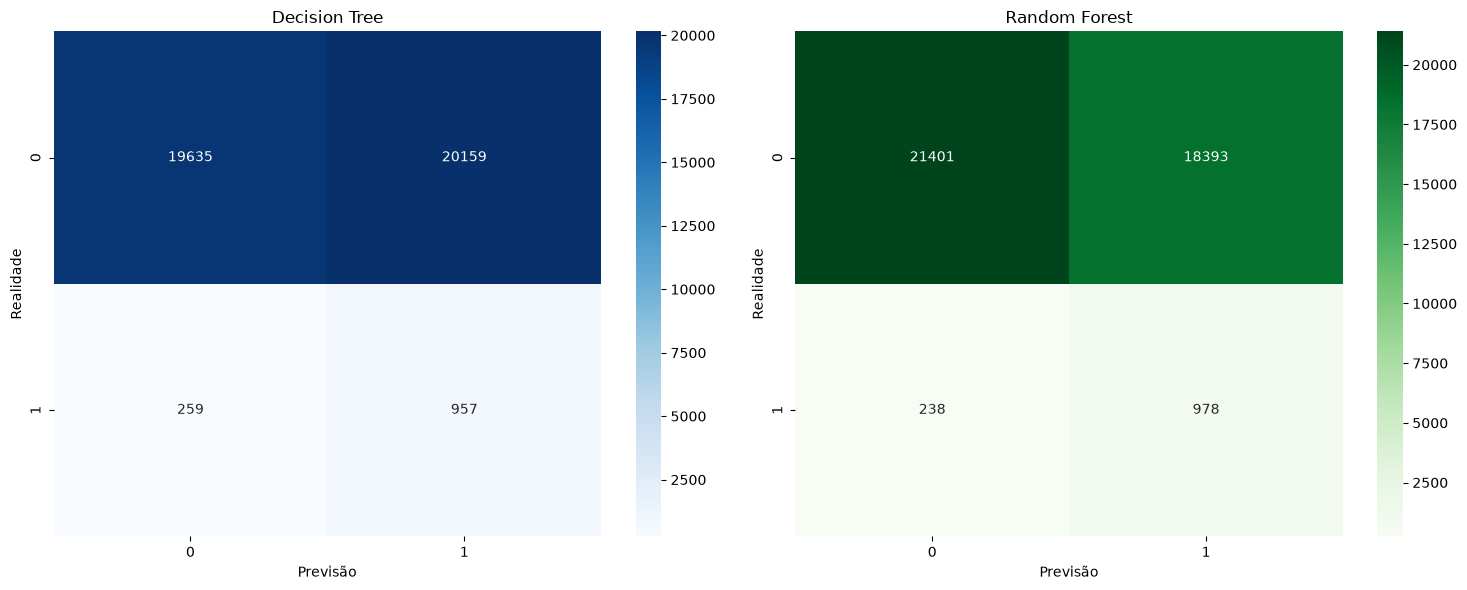

In [ ]:
# Treinando os modelos com os melhores hiperparâmetros encontrados
dt_campeao = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=2, random_state=42)
rf_campeao = RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=5, min_samples_split=10, random_state=42)

# Usaremos os dados do último fold
X_treino_final = dados_preparados[-1]['X_train']
y_treino_final = dados_preparados[-1]['y_train']
X_teste_final = dados_preparados[-1]['X_test']
y_teste_final = dados_preparados[-1]['y_test']

# Treinando os modelos
dt_campeao.fit(X_treino_final, y_treino_final)
rf_campeao.fit(X_treino_final, y_treino_final)

# Gerando previsões
y_pred_dt = dt_campeao.predict(X_teste_final)
y_pred_rf = rf_campeao.predict(X_teste_final)

# Plotando as Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Decision Tree
cm_dt = confusion_matrix(y_teste_final, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Decision Tree')
axes[0].set_ylabel('Realidade')
axes[0].set_xlabel('Previsão')

# Random Forest
cm_rf = confusion_matrix(y_teste_final, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('Previsão')

plt.tight_layout()
plt.show()

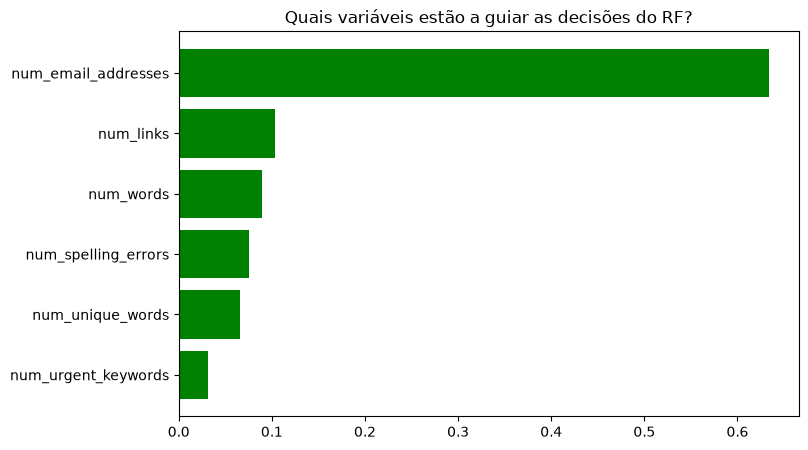

In [ ]:
importances = rf_campeao.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], align='center', color='green')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Quais variáveis estão a guiar as decisões do RF?')
plt.show()

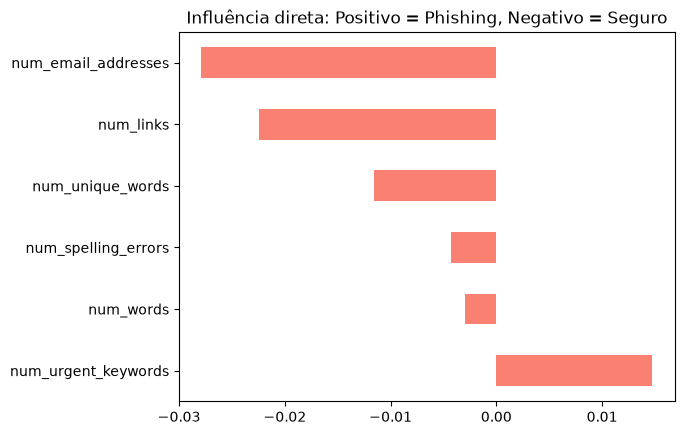

In [ ]:
# Correlação de cada feature com a classe
correlacoes = X.corrwith(y)
correlacoes.sort_values(ascending=False).plot(kind='barh', color='salmon')
plt.title('Influência direta: Positivo = Phishing, Negativo = Seguro')
plt.show()

Recall com threshold 0.4: 0.9079


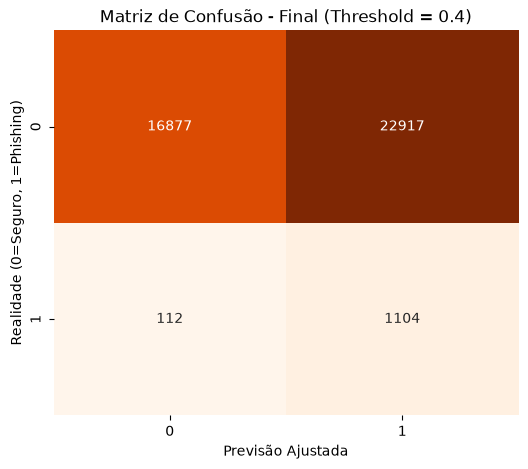

In [ ]:
# Obter as probabilidades para um em
# O modelo retorna [prob_seguro, prob_phishing]
y_probs = rf_campeao.predict_proba(X_teste_final)[:, 1]

# Aplicar o novo threshold de 0.4
# Se a probabilidade for >= 0.4, classificamos como 1 (Phishing)
novo_threshold = 0.4
y_pred_ajustado = (y_probs >= novo_threshold).astype(int)

# Printando recall final
recall_final = recall_score(y_teste_final, y_pred_ajustado, pos_label=1)
print(f"Recall com threshold 0.4: {recall_final:.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_teste_final, y_pred_ajustado)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title(f'Matriz de Confusão - Final (Threshold = {novo_threshold})')
plt.ylabel('Realidade (0=Seguro, 1=Phishing)')
plt.xlabel('Previsão Ajustada')
plt.show()

# Linear SVM

In [8]:

accs = []
f1s = []
precs = []
recalls = []

resultados = []

for c in [0.001, 0.01, 0.1, 1, 10, 100]:
  for dados in dados_preparados:
    X_treino = dados['X_train']
    y_treino = dados['y_train']
    X_teste = dados['X_test']
    y_teste = dados['y_test']

    svm_base = LinearSVC(C=c,random_state=42)

      # Treinar o modelo
    svm_base.fit(X_treino, y_treino)

    # Previsões no conjunto de teste
    y_pred_base = svm_base.predict(X_teste)

    accs.append(accuracy_score(y_teste, y_pred_base))
    precs.append(precision_score(y_teste, y_pred_base, average='weighted'))
    recalls.append(recall_score(y_teste, y_pred_base, average='weighted'))
    f1s.append(f1_score(y_teste, y_pred_base, average='weighted'))

  resultados.append({
      'Metrica': 'linear',
      'C': c,
      'Accuracy': np.mean(accs),
      'Precision': np.mean(precs),
      'Recall': np.mean(recalls),
      'F1': np.mean(f1s),
      'Accuracy_std': np.std(accs),
      'F1_std': np.std(f1s)
  })


=== Matriz de Confusão (Modelo Base) ===


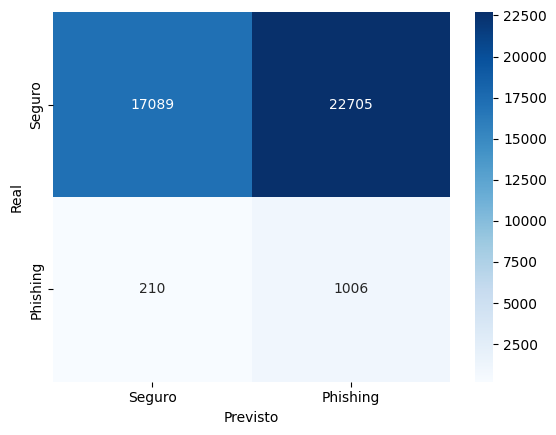


=== Relatório de Classificação (Modelo Base) ===
              precision    recall  f1-score   support

      Seguro       0.99      0.43      0.60     39794
    Phishing       0.04      0.83      0.08      1216

    accuracy                           0.44     41010
   macro avg       0.52      0.63      0.34     41010
weighted avg       0.96      0.44      0.58     41010



,Metrica,C,Accuracy,Precision,Recall,F1,Accuracy_std,F1_std
5,linear,100.000,0.433448,0.961360,0.433448,0.575183,0.007636,0.007953
4,linear,10.000,0.433426,0.961362,0.433426,0.575160,0.007635,0.007953
3,linear,1.000,0.433393,0.961366,0.433393,0.575126,0.007634,0.007952
2,linear,0.100,0.433337,0.961372,0.433337,0.575070,0.007632,0.007949
1,linear,0.010,0.433229,0.961384,0.433229,0.574960,0.007625,0.007941
0,linear,0.001,0.432963,0.961410,0.432963,0.574689,0.007601,0.007918


In [9]:
df = pd.DataFrame(resultados).sort_values(
    by='F1',
    ascending=False
)

c = df.loc[0]['C']

svm_base = LinearSVC(C=c,random_state=42)

svm_base.fit(X_treino, y_treino)

y_pred_base = svm_base.predict(X_teste)

# Avaliação da baseline
print("=== Matriz de Confusão (Modelo Base) ===")
cm_base = confusion_matrix(y_teste, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=['Seguro', 'Phishing'], yticklabels=['Seguro', 'Phishing'])
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

print("\n=== Relatório de Classificação (Modelo Base) ===")
print(classification_report(y_teste, y_pred_base, target_names=['Seguro', 'Phishing']))

df

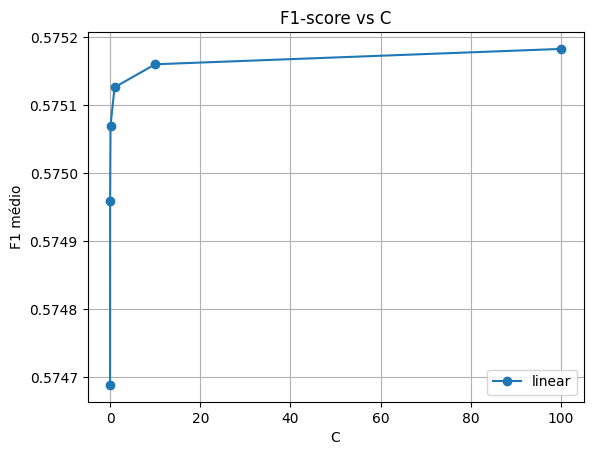

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(resultados)

plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['C'], subset['F1'], marker='o', label=metrica)

plt.title("F1-score vs C")
plt.xlabel("C")
plt.ylabel("F1 médio")
plt.legend()
plt.grid(True)
plt.show()

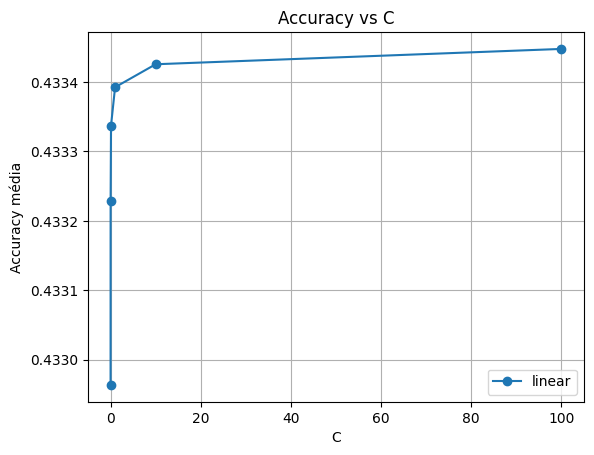

In [11]:
plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['C'], subset['Accuracy'], marker='o', label=metrica)

plt.title("Accuracy vs C")
plt.xlabel("C")
plt.ylabel("Accuracy média")
plt.legend()
plt.grid(True)
plt.show()

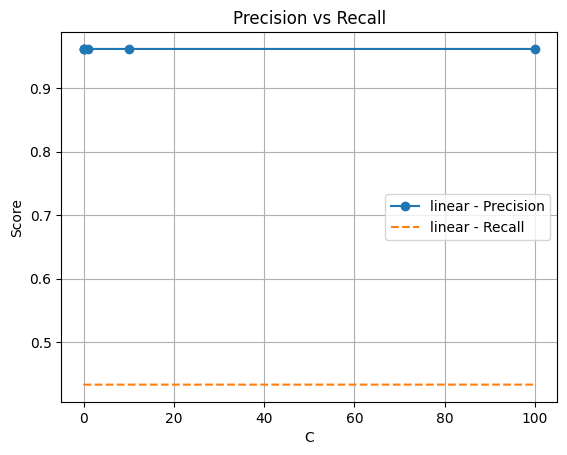

In [12]:
plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['C'], subset['Precision'], marker='o', label=f"{metrica} - Precision")
    plt.plot(subset['C'], subset['Recall'], linestyle='--', label=f"{metrica} - Recall")

plt.title("Precision vs Recall")
plt.xlabel("C")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()